In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy import linalg

In [2]:
result_dir='result/'

In [3]:
class TwoLayerNeuralField:
    def __init__(self, N, constraint_type='conv', kernel_size=5, alpha=0.05, C=100.0):
        self.N = N
        self.alpha = alpha  # Entropy/Anti-collapse
        self.C = C          # Trace constraint
        self.ctype = constraint_type
        
        if constraint_type == 'conv':
            # Learn only a small local kernel
            self.kernel = np.zeros(kernel_size)
            self.kernel[kernel_size//2] = 1.0
        else:
            # Full matrix + Mask
            self.W_full = np.eye(N) * 0.5
            dist = np.fromfunction(lambda i, j: np.minimum(np.abs(i-j), N-np.abs(i-j)), (N, N))
            self.mask = (dist <= kernel_size // 2).astype(float)
            
        self.normalize_W()
        W = self.get_W()
        A_init = W @ W.T + np.eye(self.N) * 1e-6
        self.A_init=A_init

    def normalize_W(self):
        """Strictly enforce Tr(WW^T) = C"""
        W = self.get_W()
        current_tr = np.trace(W @ W.T)
        scale = np.sqrt(self.C / current_tr)
        if self.ctype == 'conv':
            self.kernel *= scale
        else:
            self.W_full *= scale

    def get_W(self):
        if self.ctype == 'conv':
            # Build circulant W from kernel
            W = np.zeros((self.N, self.N))
            k_full = np.zeros(self.N)
            ks = len(self.kernel)
            k_full[:ks//2+1] = self.kernel[ks//2:]
            k_full[-ks//2:] = self.kernel[:ks//2+1]
            for i in range(self.N):
                W[i] = np.roll(k_full, i)
            return W
        else:
            return self.W_full * self.mask

    def update_hebbian(self,v, lr):
        W = self.get_W()
        A = W @ W.T + np.eye(self.N) * 1e-6
        A_inv = np.linalg.inv(A)
        
        # # Hebbian Gradient: dL/dW = 2*(M + alpha*A_inv - beta*I)W
        # # beta is the dynamic pressure to maintain Trace
        # beta = np.trace((M + self.alpha * A_inv) @ (W @ W.T)) / self.C
        # grad_W = 2 * (M + self.alpha * A_inv - beta * np.eye(self.N)) @ W
        
        
        v_projected = v.T @ A @ v  # Scalar: v^T (WW^T) v

        beta = (v_projected + self.alpha * self.N) / self.C
        
        # 4. Calculate grad_W
        # (vv^T @ W) is equivalent to v @ (v^T @ W) which is more efficient: O(NK) instead of O(N^2K)
        term_M_W = v.reshape(-1, 1) @ (v.reshape(1, -1) @ W)
        term_Entropy_W = self.alpha * (A_inv @ W)
        term_Trace_W = beta * W
        
        grad_W = 2 * (term_M_W + term_Entropy_W - term_Trace_W)

        
        
        if self.ctype == 'conv':
            # Project back to kernel (average across diagonals)
            dk = np.zeros_like(self.kernel)
            ks = len(self.kernel)
            for i in range(ks):
                offset = i - ks//2
                dk[i] = np.mean(np.diag(grad_W, k=offset) if offset>=0 else np.diag(grad_W, k=self.N+offset))
            self.kernel += lr * dk
        else:
            self.W_full += lr * grad_W * self.mask
            
        self.normalize_W()

In [4]:
def get_gradients(N, mode='local'):
    x = np.linspace(0, 1, N)
    if mode == 'local':
        # 1. Localized: Only neurons near center care about s
        # return np.exp(-(x - 0.5)**2 / (2 * 0.05**2)).reshape(-1, 1)
        return np.sin(x * 0.5) * np.exp(-0.5 * (x / 15.0)**2) # High freq sensitivity
    
    elif mode == 'global_shift':
        # 2. Global: A wave-like gradient across all neurons
        # return np.sin(2 * np.pi * x).reshape(-1, 1)
        return np.exp(-0.5 * (x / 6.0)**2) # Low freq sensitivity
    
    elif mode == 'mean_field':
        # 3. Mean Field: All neurons care equally
        a=np.ones((N, 1))
        # a[:N//50]=-1
        return a#np.random.choice([1, -1], size=N)#np.ones((N, 1))

In [12]:
def calculate_xi_field_theory(A, N):
    """
    Corrected Ginzburg-Landau correlation length calculation.
    xi = sqrt(kappa / m^2)
    """
    # 1. Get eigenvalues and eigenvectors
    # We use eigh because A is symmetric
    vals, vecs = np.linalg.eigh(A)
    
    # Sort them just in case (eigh usually returns sorted)
    idx = np.argsort(vals)
    vals = vals[idx]
    vecs = vecs[:, idx]
    
    # 2. Identify the 'Mass' (Soft Mode eigenvalue)
    # This is the precision gap. If A is singular, m2 -> 0
    m2 = vals[0]
    
    # 4. Compute Correlation Length
    # Use a small epsilon to avoid division by zero at the critical point
    epsilon = 1e-12
    xi = np.sqrt(1 / (m2 + epsilon))
    
    # 5. Finite Size Clipping
    # Physical xi cannot meaningfully exceed the system size N
    return min(xi, N)

In [6]:
def calculate_xi_fourier_method(A, N):
    """
    基于傅立叶谱（功率谱）计算相关长度。
    假设 A 是平稳高斯场，提取其第一行作为核。
    """
    # 1. 提取 A 的第一行（代表空间相互作用核）
    # 如果 A 不是完美的 Toeplitz，可以对所有行取平均以增强鲁棒性
    # kernel = A[0, :] 
    mid_row = A[N // 2, :]
    kernel = np.roll(mid_row, -(N // 2))
    
    
    # 2. 变换到频率空间 (Power Spectrum of Precision)
    # A_k 对应的是精度谱，C_k = 1/A_k 才是相关谱
    A_k = np.real(np.fft.fft(kernel))

    freqs = np.fft.fftfreq(N) * (2 * np.pi) # 转换为弧度频率
    
    # 3. 找到基态频率 (通常是 k=0，或者 A_k 最小的地方)
    idx_min = np.argmin(np.abs(A_k))
    m2 = A_k[idx_min]
    
    # 4. 计算曲率 kappa
    # 找到基态旁边的邻居频率点
    idx_neighbor = (idx_min + 1) % N
    delta_k_sq = (freqs[idx_neighbor] - freqs[idx_min])**2
    
    kappa = (A_k[idx_neighbor] - A_k[idx_min]) / delta_k_sq
    
    # 5. 计算相关长度
    xi = np.sqrt(np.abs(kappa / (m2 + 1e-12)))
    
    return min(xi, N)

In [7]:
def calculate_branching_ratio(W):
    """
    The branching ratio sigma is the spectral radius of the 
    effective interaction matrix W.
    """
    # Compute eigenvalues of the learned W
    eigvals = np.linalg.eigvals(W)
    sigma = np.max(np.abs(eigvals))
    return sigma

In [24]:
constraint=['conv','mask']
modes=['local','global_shift','mean_field']
N_arr=np.array([100,200,300,400,500,600])#

C = 200.0
kernel_s=10
H_weight=0.0

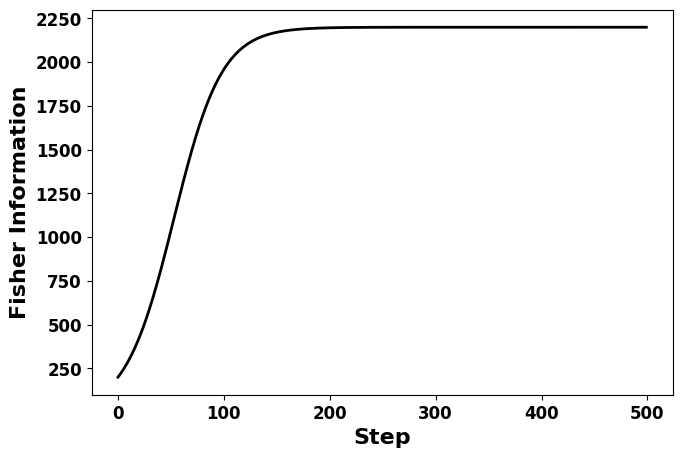

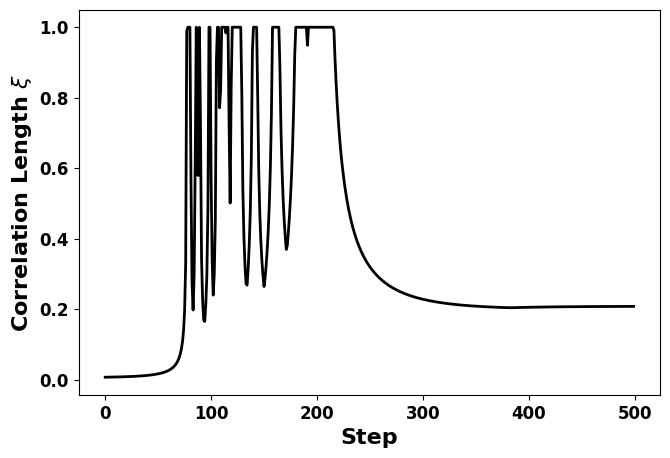

199.99999999999991 200.00010000000006


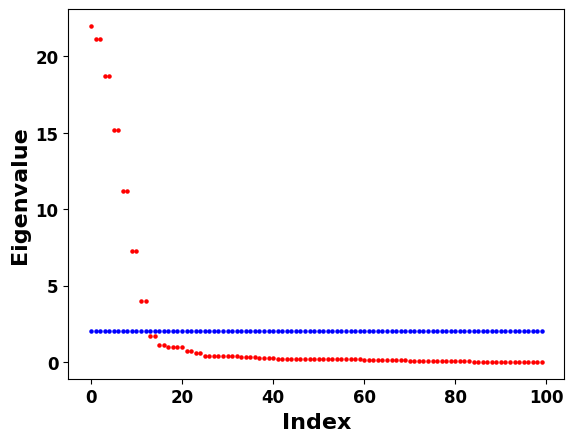

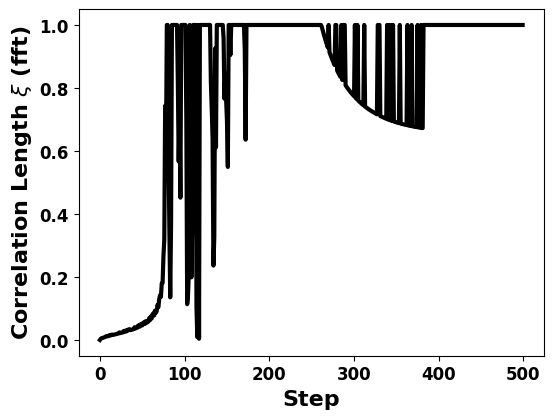

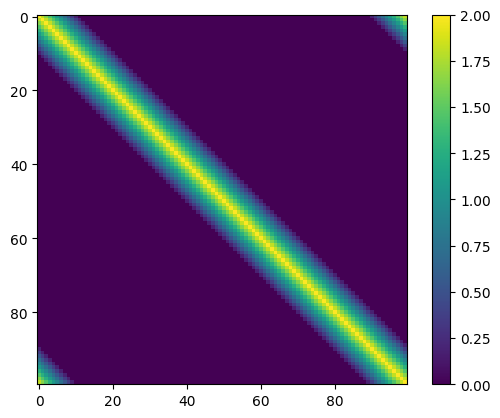

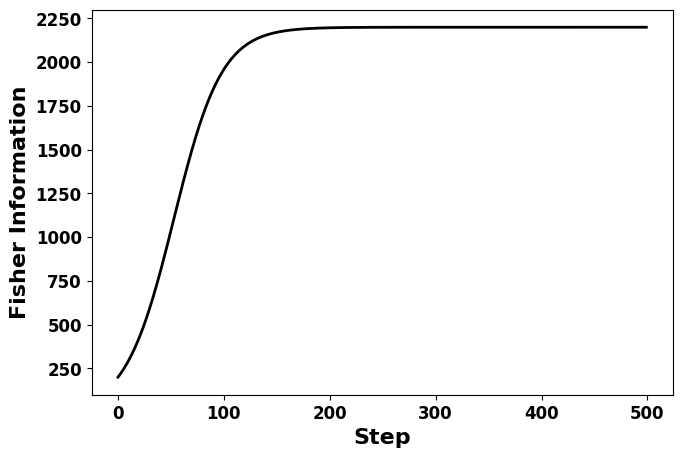

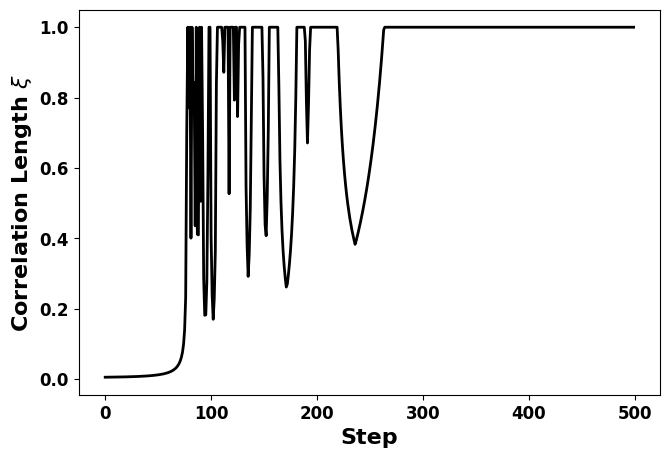

199.99999999999994 200.00019999999995


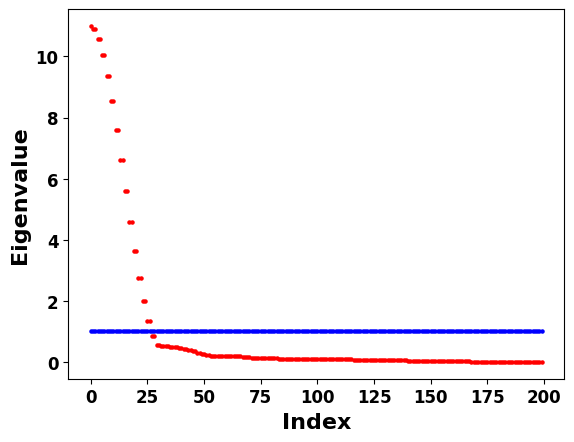

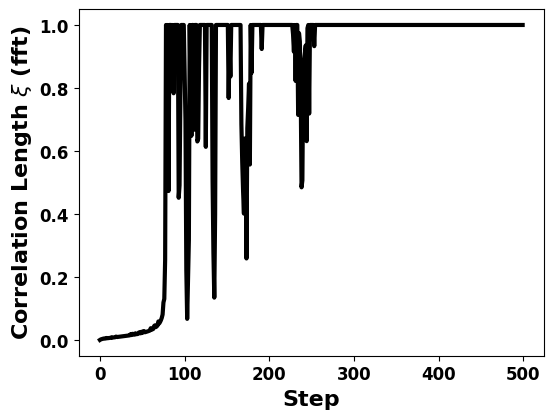

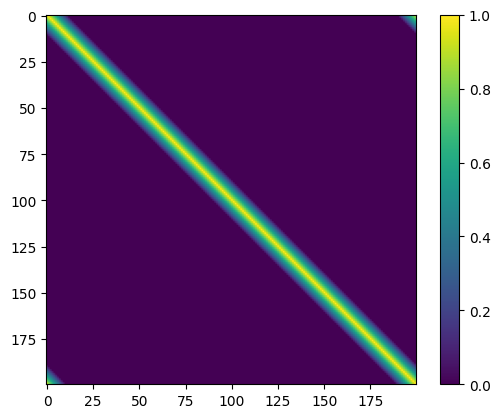

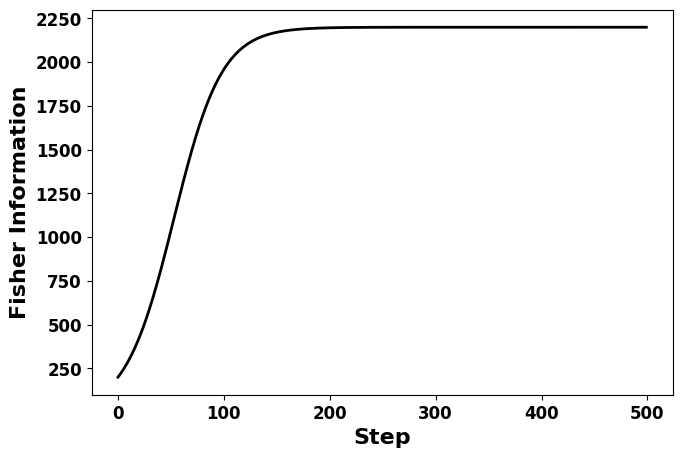

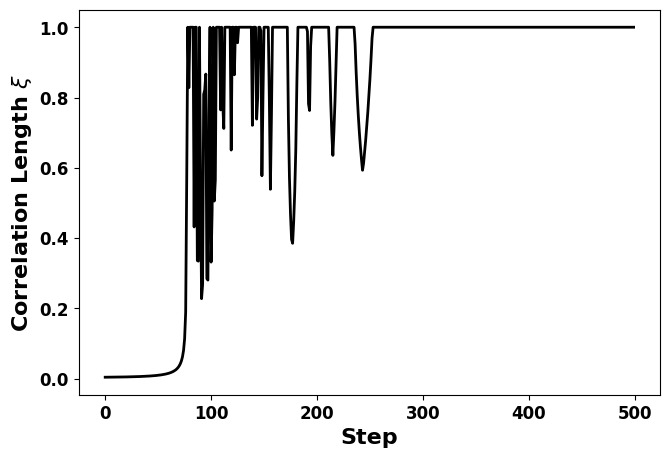

199.99999999999994 200.00030000000004


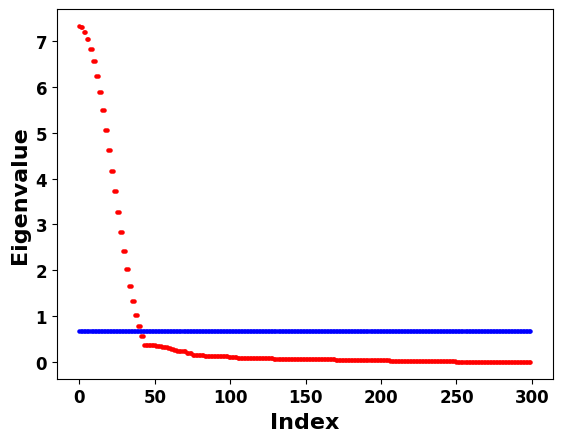

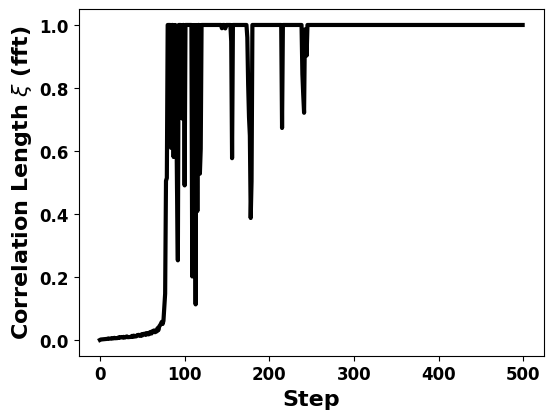

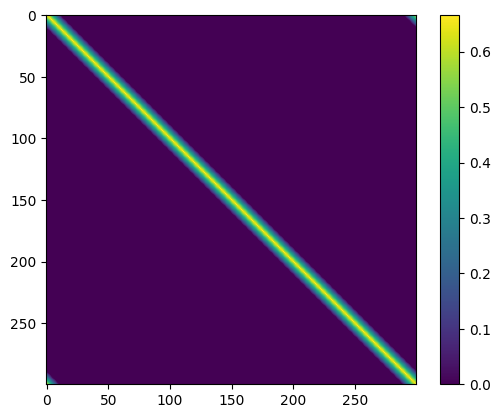

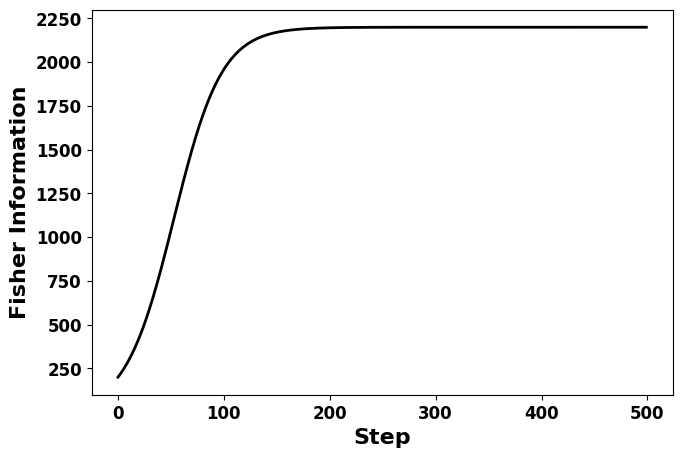

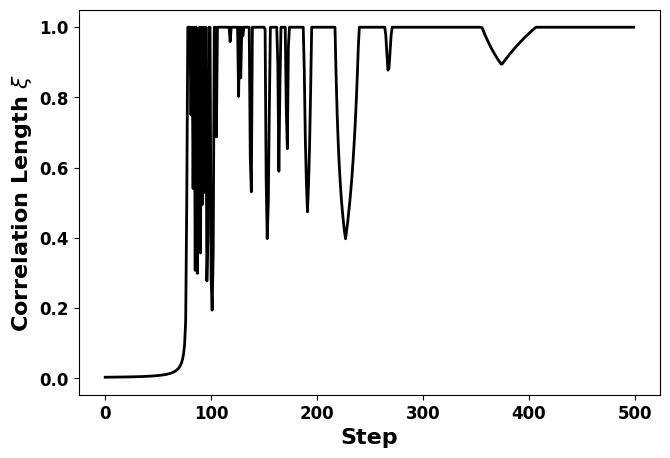

199.99999999999994 200.00040000000007


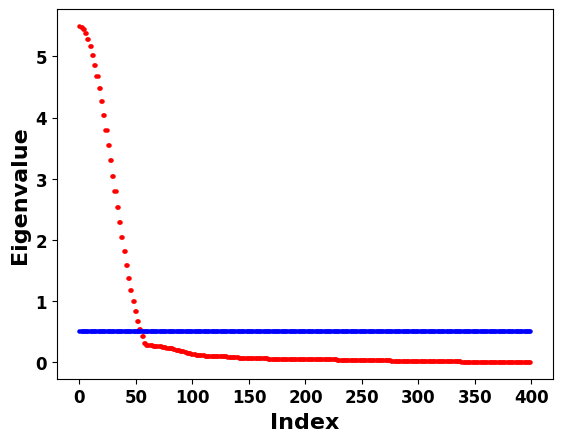

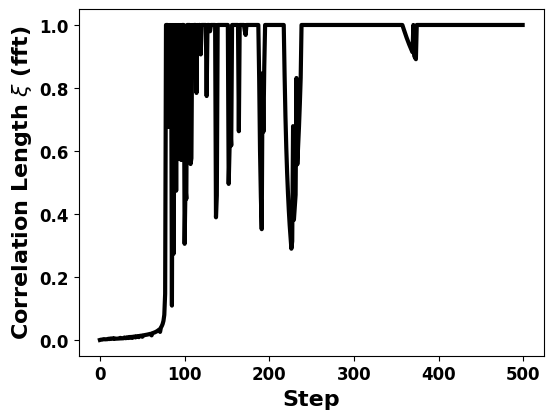

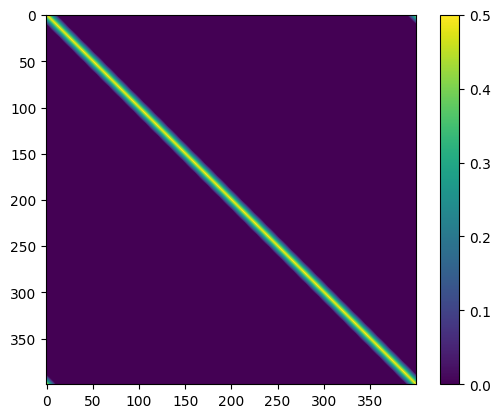

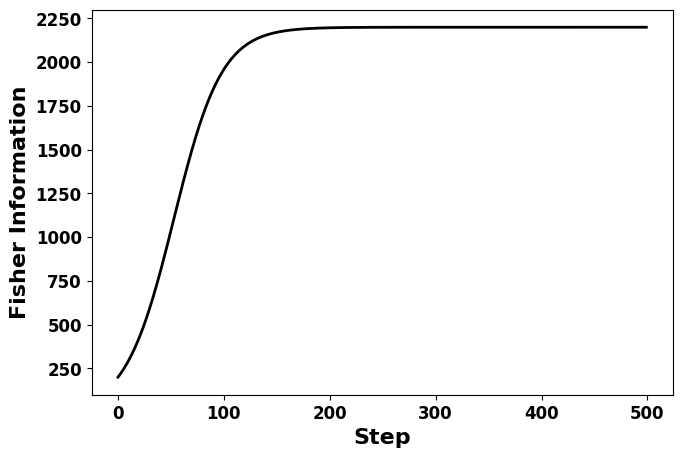

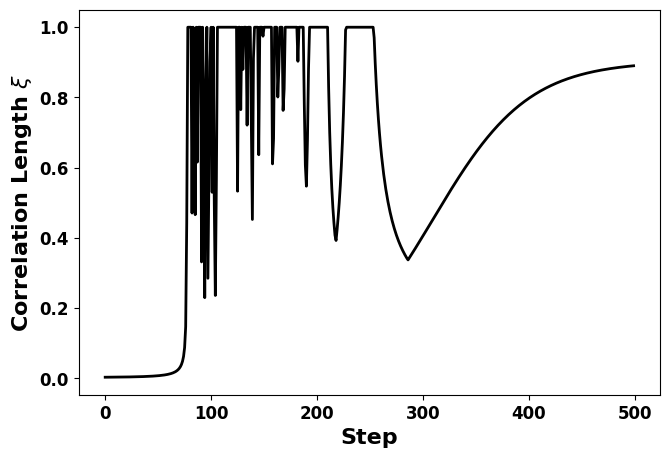

199.99999999999994 200.00049999999993


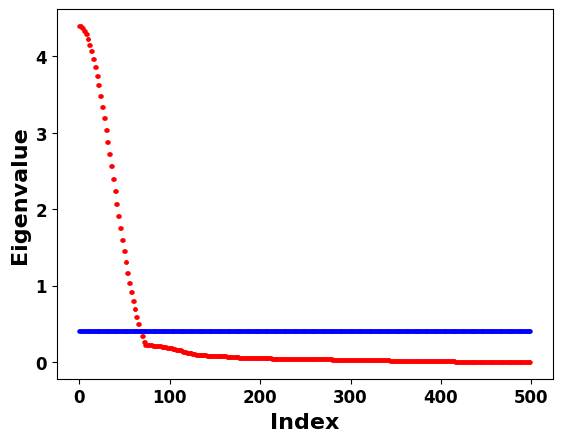

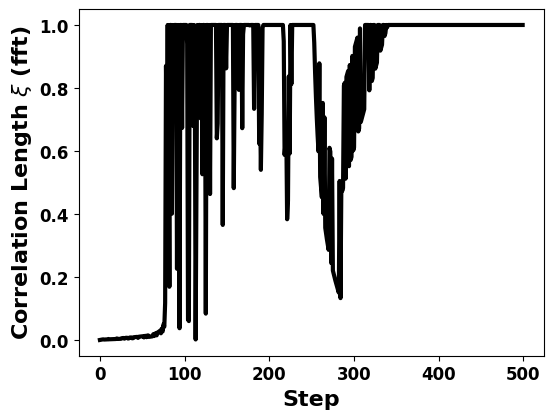

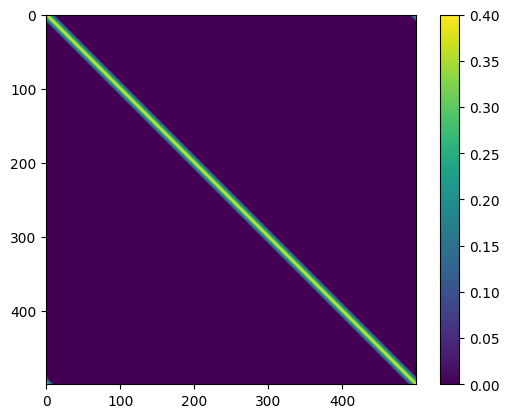

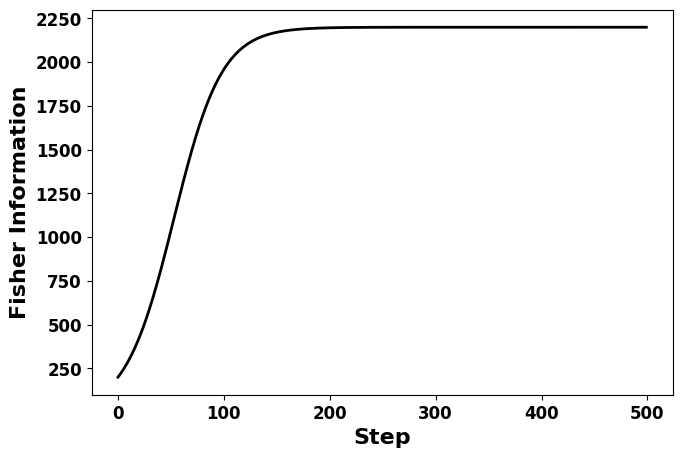

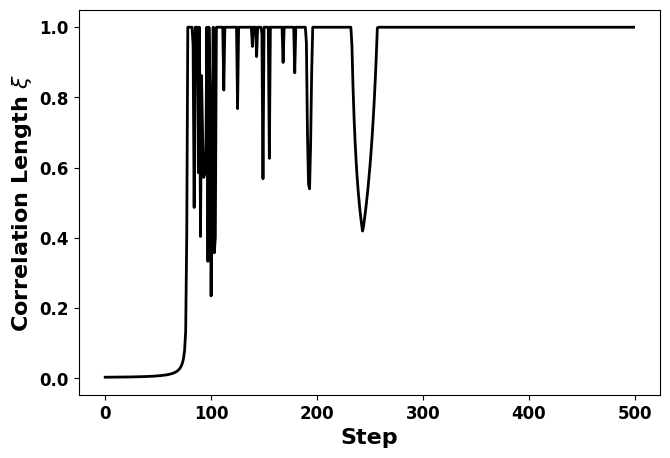

199.99999999999994 200.00059999999993


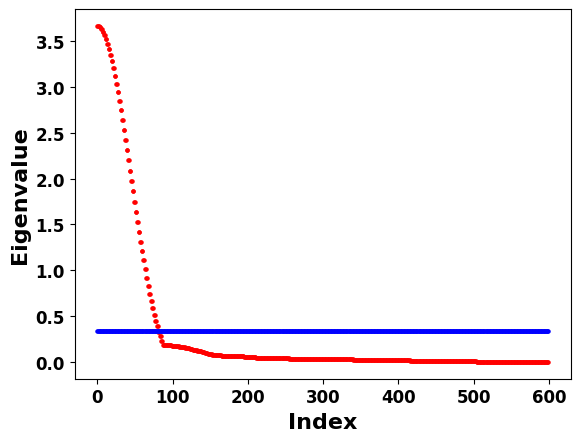

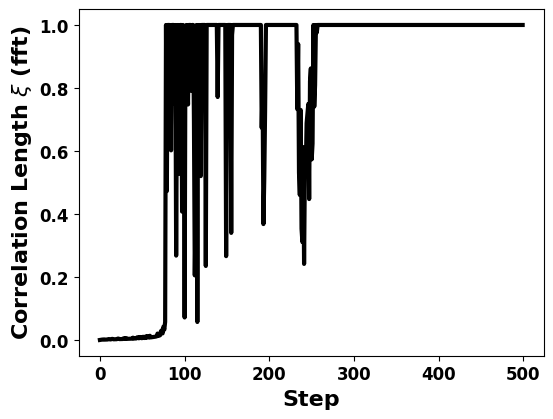

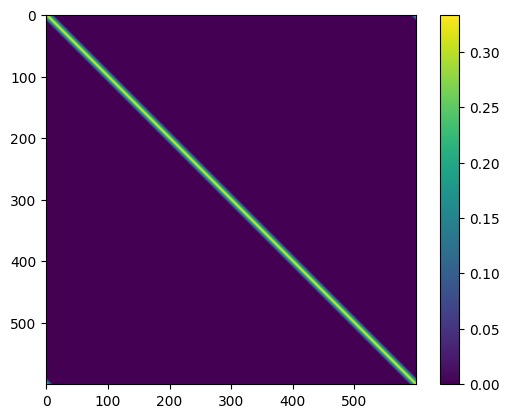

In [27]:
A_arr=[]
W_arr=[]
Ai_arr=[]
for N in N_arr:

    constraint='mask'
    mode='mean_field'
    
    f_prime = get_gradients(N, mode=mode)
    
    model = TwoLayerNeuralField(N, constraint_type=constraint,kernel_size=kernel_s, alpha=H_weight, C=C)
    
    h_fisher, h_xi,h_xi_fft,h_bf= [], [],[],[]
    for _ in range(500):
        W = model.get_W()
        A = W @ W.T
        fi=f_prime.T @ A @ f_prime
        h_fisher.append(fi.item())
        
        # # Calculate xi: sqrt(kappa/m^2)
        # vals = np.sort(np.linalg.eigvalsh(A))
        # m2 = vals[0]
        # kappa = (vals[1] - vals[0]) / ((2*np.pi/N)**2)
        # h_xi.append(np.sqrt(np.abs(kappa/(m2 + 1e-9))))
        h_xi.append(calculate_xi_field_theory(A, N))
        h_xi_fft.append(calculate_xi_fourier_method(A, N))
        
        
        h_bf.append(calculate_branching_ratio(W))
        
        model.update_hebbian(f_prime, lr=0.001)
    
    A_arr.append(A)
    W_arr.append(model.get_W)
    Ai_arr.append(model.A_init)
    # Wi_arr.append(model.W_init)
    # np.save(result_dir+'A'+str(N)+'_mat.npy',A)


    plt.figure(figsize=(7.5, 5))
    plt.plot(h_fisher,linewidth=2,color='black')
    plt.xticks(fontsize=12,fontweight='bold')
    plt.yticks(fontsize=12,fontweight='bold')
    plt.xlabel('Step', fontsize=16,fontweight='bold')
    plt.ylabel('Fisher Information', fontsize=16,fontweight='bold')
    plt.savefig(result_dir+str(N)+'homo_FI.png',bbox_inches='tight',dpi=300)
    plt.show()
    
    plt.figure(figsize=(7.5, 5))
    plt.plot(np.array(h_xi)/N,linewidth=2,color='black')
    plt.xticks(fontsize=12,fontweight='bold')
    plt.yticks(fontsize=12,fontweight='bold')
    plt.xlabel('Step', fontsize=16,fontweight='bold')
    plt.ylabel('Correlation Length $\\xi$', fontsize=16,fontweight='bold')
    plt.savefig(result_dir+str(N)+'homo_corr_length.png',bbox_inches='tight',dpi=300)
    plt.show()

    vals,_ =np.linalg.eigh(A)
    vals_init,_ =np.linalg.eigh(model.A_init)
    print(np.sum(vals),np.sum(vals_init))
    plt.scatter(np.arange(N),np.sort(vals)[::-1],s=5,color='r')
    plt.scatter(np.arange(N),np.sort(vals_init)[::-1],s=5,color='b')
    plt.xlabel('Index', fontsize=16,fontweight='bold')
    plt.ylabel('Eigenvalue', fontsize=16,fontweight='bold')
    plt.xticks(fontsize=12,fontweight='bold')
    plt.yticks(fontsize=12,fontweight='bold')
    plt.savefig(result_dir+str(N)+'homo_eigen.png',bbox_inches='tight',dpi=300)
    plt.show()

    plt.figure(figsize=(6, 4.5))
    plt.plot(np.array(h_xi_fft)/N,linewidth=3,color='black')
    plt.xticks(fontsize=12,fontweight='bold')
    plt.yticks(fontsize=12,fontweight='bold')
    plt.xlabel('Step', fontsize=16,fontweight='bold')
    plt.ylabel('Correlation Length $\\xi$ (fft)', fontsize=16,fontweight='bold')
    # plt.savefig(result_dir+'corr_length.png',dpi=300)
    plt.show()


    
    plt.imshow(A)
    plt.colorbar()
    plt.show()
    
    # plt.hist(np.diag(A))
    # plt.show()
    # print(np.sum(np.diag(A)))

In [28]:
# --- Analysis & Power Law Plotting ---
def plot_power_law(data, label, ax, title):
    # Log-binning for cleaner visualization
    counts, bins = np.histogram(data, bins=np.logspace(np.log10(min(data)), np.log10(max(data)),20))
    x = (bins[:-1] + bins[1:]) / 2
    y = counts / np.diff(bins) # Density
    
    # Remove zeros for log-log fit
    mask = y > 0
    x, y = x[mask][:], y[mask][:]

    
    # Fit: log(y) = -tau * log(x) + C
    slope, intercept, r, p, std = linregress(np.log10(x), np.log10(y))
    
    ax.loglog(x, y, 'o', label=f'{label} (slope={slope:.2f})')
    ax.loglog(x, 10**intercept * x**slope, '--', alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.set_ylabel('Probability Density')
    ax.legend()

In [29]:
def analyze_spectral_criticality(A_matrix, tol=1e-9):
    """
    Quantifies the criticality of a neural system using spectral methods.
    
    Args:
        A_matrix (np.ndarray): The NxN symmetric precision matrix (inverse covariance).
                               Represents the energy landscape curvature.
        tol (float): Threshold to treat eigenvalues as effectively zero.
        
    Returns:
        dict: Dictionary containing:
            - 'spectral_gap': The smallest non-zero eigenvalue (lambda_min).
            - 'correlation_length': Effective spatial range (xi).
            - 'ipr': Inverse Participation Ratio of the softest mode (Y).
            - 'is_critical': Boolean flag if system is near criticality.
    """
    # 1. Eigen-decomposition (using eigh for symmetric/Hermitian matrices)
    # eigenvalues are returned in ascending order
    evals, evecs = linalg.eigh(A_matrix)
    
    # 2. Identify the "Softest Mode" (Mass Term)
    # In a precision matrix, the smallest eigenvalue corresponds to the 
    # flattest direction in the energy landscape (highest variance).
    lambda_min = evals[0]
    
    # Handle numerical instability if lambda_min is practically zero (Goldstone mode)
    if lambda_min < tol:
        xi = np.inf
    else:
        # Formula: xi ~ 1 / sqrt(lambda_min)
        xi = 1.0 / np.sqrt(lambda_min)
        
    # 3. Compute Inverse Participation Ratio (IPR)
    # IPR quantifies the spatial extent of the eigenmode.
    # Y = sum(u_i^4) for normalized u.
    # If Y ~ 1/N -> Delocalized (Critical/Collective state).
    # If Y ~ 1   -> Localized (Single neuron state).
    
    u_soft = evecs[:, 0]  # Eigenvector corresponding to lambda_min
    
    # Ensure normalization (eigh usually returns normalized vectors, but good to be safe)
    u_soft = u_soft / np.linalg.norm(u_soft)
    
    ipr = np.sum(u_soft ** 4)
    
    return {
        "spectral_gap": lambda_min,
        "correlation_length": xi,
        "ipr": ipr,
        "regime": "Delocalized (Critical)" if ipr < (2.0 / len(A_matrix)) else "Localized",
        "soft_mode_vector": u_soft
    }

In [30]:
ipr_n=[]
for A in A_arr:
    results = analyze_spectral_criticality(A)
    
    print(f"Spectral Gap (Mass^2): {results['spectral_gap']:.4f}")
    print(f"Correlation Length:      {results['correlation_length']:.4f}")
    print(f"IPR (Localization):      {results['ipr']:.4f}")
    print(f"Regime:                  {results['regime']}")
    ipr_n.append(results['ipr'])

Spectral Gap (Mass^2): 0.0023
Correlation Length:      20.7990
IPR (Localization):      0.0150
Regime:                  Delocalized (Critical)
Spectral Gap (Mass^2): 0.0000
Correlation Length:      211.3216
IPR (Localization):      0.0075
Regime:                  Delocalized (Critical)
Spectral Gap (Mass^2): 0.0000
Correlation Length:      358.0047
IPR (Localization):      0.0050
Regime:                  Delocalized (Critical)
Spectral Gap (Mass^2): 0.0000
Correlation Length:      443.7838
IPR (Localization):      0.0038
Regime:                  Delocalized (Critical)
Spectral Gap (Mass^2): 0.0000
Correlation Length:      445.0958
IPR (Localization):      0.0030
Regime:                  Delocalized (Critical)
Spectral Gap (Mass^2): 0.0000
Correlation Length:      603.3511
IPR (Localization):      0.0025
Regime:                  Delocalized (Critical)


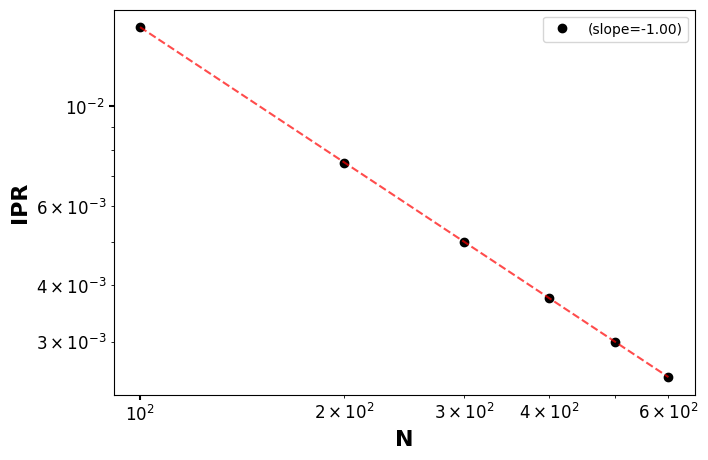

In [31]:

ipr_arr=np.array(ipr_n)
slope, intercept, r, p, std = linregress(np.log10(N_arr), np.log10(ipr_arr))


plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5

fig,ax=plt.subplots(figsize=(7.5, 5))
ax.loglog(N_arr, ipr_arr, 'o', color='black', label=f'(slope={slope:.2f})')
ax.loglog(N_arr, 10**intercept * N_arr**slope, '--', alpha=0.7,color='red')

plt.xlabel('N',fontsize=16,fontweight='bold')
plt.ylabel('IPR',fontsize=16,fontweight='bold')


plt.legend()
plt.savefig(result_dir+'homo_IPR.png',bbox_inches='tight',dpi=300)
plt.show()

In [33]:
# --- Analysis & Power Law Plotting ---
def plot_power_law(data, label, ax, title, num_bins=None):
    """
    Plot power law distribution with adaptive binning.
    
    Parameters:
    - data: array-like, the data to plot
    - label: str, label for the data
    - ax: matplotlib axis, axis to plot on
    - title: str, title for the plot
    - num_bins: int or None, if None uses adaptive binning based on data size
    """
    # Adaptive binning based on data size
    if num_bins is None:
        # Use Freedman-Diaconis rule for bin width selection
        n = len(data)
        if n > 1000:
            # For large datasets, use more bins
            num_bins = int(np.sqrt(n))
        else:
            # For smaller datasets, use fewer bins
            num_bins = max(10, int(n / 50))
    
    # Ensure we have at least 5 bins and at most 50 bins
    num_bins = max(5, min(50, num_bins))
    
    # Log-spaced bins
    bins = np.logspace(np.log10(max(min(data), 1e-10)),  # Avoid log(0)
                      np.log10(max(data)), 
                      num_bins + 1)
    
    # Calculate histogram
    counts, bins = np.histogram(data, bins=bins)
    x = (bins[:-1] + bins[1:]) / 2
    y = counts / np.diff(bins)  # Probability density
    
    # Remove zeros for log-log fit
    mask = (y > 0) & (x > 0)
    x_fit, y_fit = x[mask], y[mask]
    
    # Check if we have enough points for fitting
    if len(x_fit) < 3:
        ax.loglog(x, y, 'o', label=f'{label} (insufficient data for fit)')
        ax.set_title(title)
        ax.set_xlabel('Value')
        ax.set_ylabel('Probability Density')
        ax.legend()
        return
    
    # Fit: log(y) = -tau * log(x) + C
    slope, intercept, r_value, p_value, std_err = linregress(np.log10(x_fit), np.log10(y_fit))
    
    # Plot data and fit
    ax.loglog(x, y, 'o', markersize=8, color='cyan',alpha=0.7, label=f'{label}')
    ax.loglog(x_fit, 10**intercept * x_fit**slope, '--', alpha=0.8, 
              linewidth=2,color='black', label=f'Fit: slope={slope:.2f}')
    
    # Add R² value if correlation is high
    if abs(r_value) > 0.8:
        ax.text(0.05, 0.95, f'R² = {r_value**2:.3f}', 
                transform=ax.transAxes, fontsize=9,
                verticalalignment='top')
    
    # ax.set_title(title)
    ax.set_xlabel(label,fontsize=16, fontweight='bold')
    ax.set_ylabel('Probability Density',fontsize=16, fontweight='bold')
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3, which='both')

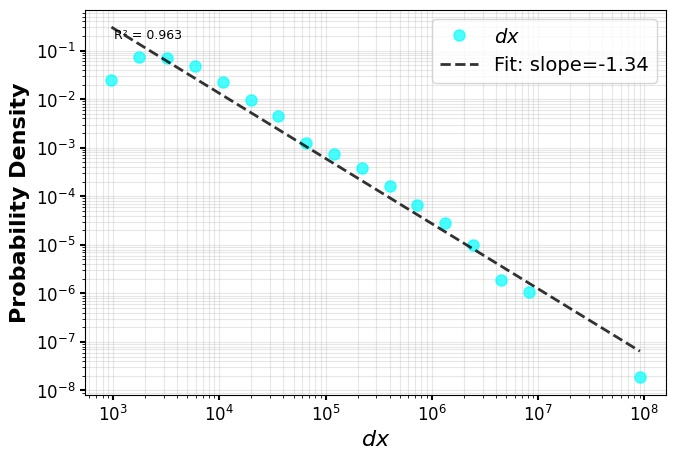

In [35]:
def simulate_quench_avalanche(A, N, num_quenches=1000):
    """
    模拟 Quench 动力学中的雪崩 (Response Avalanche)。
    核心逻辑：统计对于微小的参数变化 delta_A，系统状态变化 delta_x 的分布。
    """

    
    # 2. 初始化系统状态
    # 我们需要一个非零的“外场”或“输入” y，使得 x 有非零的平衡位置
    # Ax = y  => x = A^-1 y
    y = 0.1*np.random.randn(N)
    x_current = np.linalg.solve(A, y)
    
    avalanche_sizes = []
    # durations=[]

    # # 时间轴 (用于积分)
    # t_eval = np.logspace(1, 10, 2000) # 覆盖快慢尺度
    
    # 3. 循环执行 Quench 实验
    for _ in range(num_quenches):
        # y = 0.1*np.random.randn(N)
        # x_current = np.linalg.solve(A, y)

        
        # --- A. 施加微扰 (The Quench) ---
        # 这种扰动模拟突触权重的微小漂移或学习更新
        # 强度必须很小，否则系统会彻底崩溃



        
        perturbation_strength = 1e-6
        R = np.random.randn(N, N)
        delta_A = perturbation_strength * (R + R.T) # 对称扰动
        
        # --- B. 计算新的平衡态 ---
        A_new = A + delta_A
        
        # 检查正定性 (可选，防止数值爆炸)
        # 在微小扰动下，Sloppy 系统的软模极易变负，这里简单处理：
        # 如果奇异，则跳过统计（或视为无穷大雪崩）


        x_new = np.linalg.solve(A_new, y)
            
        # --- C. 提取雪崩规模 (Avalanche Size) ---
        # 定义：状态向量在相空间中的位移距离
        dx = x_new - x_current
        size = np.linalg.norm(dx)
        
        avalanche_sizes.append(size)


        # --- D. 更新系统 ---
        # 让系统演化下去 (Cumulative Aging) 
        # 或者重置 A (Independent Samples)
        # 这里选择 Cumulative，模拟真实系统的连续演化
        A = A_new 
        x_current = x_new
        

    return np.array(avalanche_sizes)

# --- 运行 ---
sizes = simulate_quench_avalanche(A,model.N)


fig,ax=plt.subplots(figsize=(7.5, 5))
plot_power_law(sizes, '$dx$', ax, "Avalanche Size Distribution")
plt.savefig(result_dir+'homo_dx_powerlaw.png',bbox_inches='tight',dpi=300)